# Week 8 Activity: Onset Detection and Autocorrelation

Complete this activity as part of your participation grade. Pending length of the lecture, you will have time in class to work. Everything you need to complete this activity can be found in this week's (or a previous week's) lecture code.

In [ ]:
import librosa, librosa.display
from collections import Counter
from scipy.io.wavfile import read
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np

## Onset Detection

Read in the following files below, and normalize.

a) 80sPopDrums.wav  
b) TheBlackKeys_track4.wav (use random 10s from near middle of track)  
c) prelude_cmaj_10s.wav  

In [ ]:
(fs, x) = read('../audio/80sPopDrums.wav')
xn = x/max(abs(x))

In [160]:
(fs, x) = read('../audio/TheBlackKeys_track4.wav')
xn = x/max(abs(x))
xn = xn[600000:(600000+10*fs)]

In [182]:
(fs, x) = read('../audio/prelude_cmaj_10s.wav')

# its stereo so we're just gonna take the left channel
x = x[:,0]
xn = x/max(abs(x))

#### For each of the tracks (start with just one):

1) Compute the energy and RMSE for each track using a frame length of your choice  
2) Plot the energy and the RMSE
3) Use one of the energy features to create your novelty function and plot
4) Write a peak picking function to define onsets from your novelty function
4) Based on the plots, estimate what an appropriate 'threshold' would be. Does the threshold change across tracks? If so, what could you do to put them on a similar scale?

In [183]:
hop_length = 512
frame_length = 1024
energy = np.array([sum(abs(xn[i:i+frame_length]**2)) for i in range(0, len(xn), hop_length)])
rmse = librosa.feature.rms(y=xn, frame_length=frame_length, hop_length=hop_length, center=True)

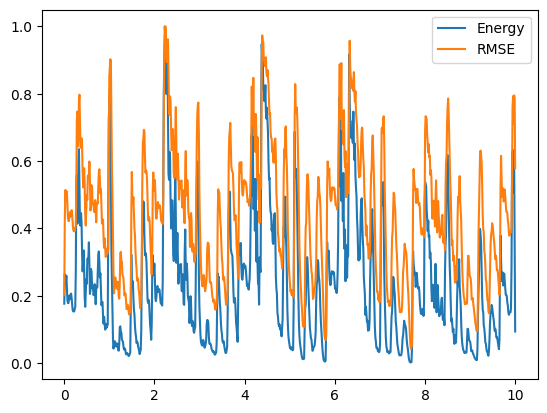

In [184]:
frames=range(len(rmse[0]))
t = librosa.frames_to_time(frames, sr=fs, hop_length=hop_length)
plt.plot(t, energy/max(abs(energy)), label='Energy')
plt.plot(t, rmse[0]/max(abs(rmse[0])), label='RMSE')
plt.legend()

In [185]:
rmse_diff = np.diff(rmse[0])
novelty = np.concatenate((rmse_diff, np.array([0])))  # Add a zero at the end to maintain the same length
novelty[novelty < 0] = 0

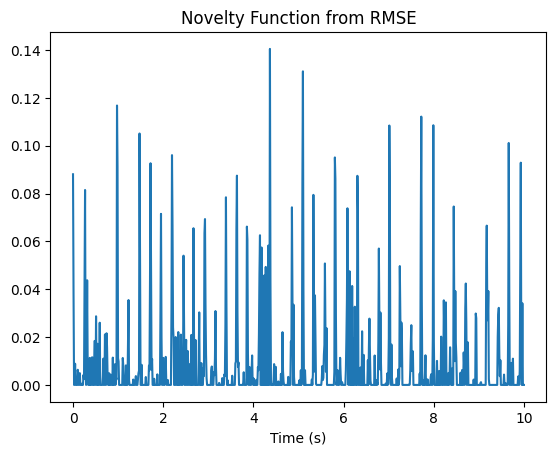

In [186]:
plt.plot(t, novelty, label='Novelty Function')
plt.xlabel('Time (s)')
plt.title('Novelty Function from RMSE')

In [187]:
peaks, properties = signal.find_peaks(novelty, height=0.05)
peak_times = t[1:][peaks]
peak_times

array([0.27863946, 0.98684807, 1.4860771 , 1.72988662, 1.96208617,
       2.20589569, 2.46131519, 2.68190476, 2.93732426, 3.40172336,
       3.64553288, 3.86612245, 4.15637188, 4.19120181, 4.34213152,
       4.37696145, 4.8645805 , 5.10839002, 5.34058957, 5.59600907,
       5.81659864, 6.0952381 , 6.31582766, 6.79183673, 7.02403628,
       7.7322449 , 7.99927438, 8.45206349, 9.18349206, 9.67111111,
       9.93814059])

In [188]:
# it seems like most of the significant peaks are above 0.05 for the first audio track

# the peaks are kind of all over the place in the second track, but honestly 0.05 still seems like an acceptable
# threshold

# ok yeah it seems like the significant, evenly spaced peaks happen above 0.05 here also, some wierdness might
# still fall into that threshold but i think it will be okay

## Tempo Estimation

Using your novelty functions and detected onsets above, estimate the global tempo of the files using autocorrelation and IOIs.

1) IOI Based Tempo

- Compute Inter-Onset Intervals (IOIs)
- Convert IOIs to BPM
- Create a beat histogram to help you infer tempos

In [189]:
iois = np.diff(peak_times)
iois

array([0.70820862, 0.49922902, 0.24380952, 0.23219955, 0.24380952,
       0.2554195 , 0.22058957, 0.2554195 , 0.46439909, 0.24380952,
       0.22058957, 0.29024943, 0.03482993, 0.15092971, 0.03482993,
       0.48761905, 0.24380952, 0.23219955, 0.2554195 , 0.22058957,
       0.27863946, 0.22058957, 0.47600907, 0.23219955, 0.70820862,
       0.26702948, 0.45278912, 0.73142857, 0.48761905, 0.26702948])

In [190]:
num_counts = Counter(iois)
top_n = num_counts.most_common(3)
top_n

[(0.2205895691609978, 4), (0.25541950113378675, 3), (0.2438095238095237, 2)]

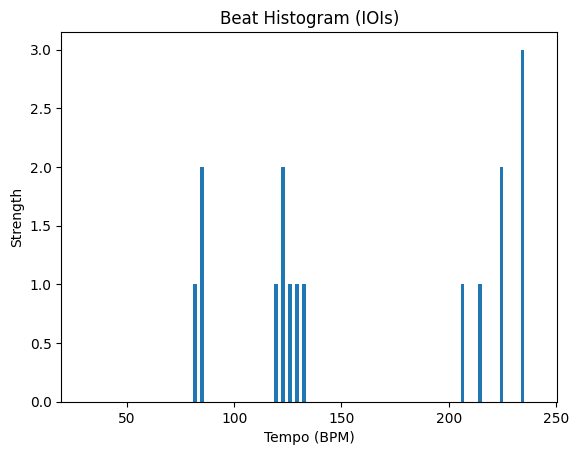

In [208]:
tempos = 60/iois
n, bins, _ = plt.hist(tempos, range=(30,240), bins=128)
plt.title("Beat Histogram")
plt.xlabel("Tempo (BPM)")
plt.ylabel("Strength")
plt.title("Beat Histogram (IOIs)")

In [205]:
bins[np.argpartition(n, -5)[-5:]]

array([131.71875 ,  84.140625, 121.875   , 233.4375  , 223.59375 ])

2) Autocorrelation based Tempo
- Compute the autocorrelation of your novelty function
- Convert lag to BPMs (conside perceptual relevance)
- Crate a beat histogram to help you infer tempos

In [193]:
ac = librosa.autocorrelate(novelty)

In [194]:
lags = np.arange(len(ac))
lag_times = lags * hop_length / fs
bpms = 60 / lag_times[1:]
strength = ac[1:]

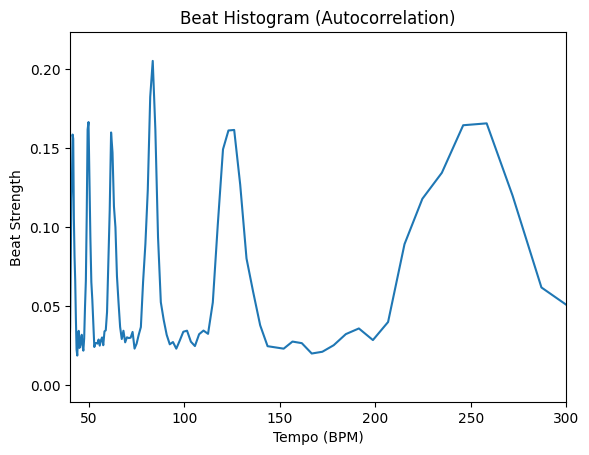

In [195]:
plt.plot(bpms, strength)
plt.xlim(40, 300)
plt.xlabel("Tempo (BPM)")
plt.ylabel("Beat Strength")
plt.title("Beat Histogram (Autocorrelation)")

In [203]:
# stack overflow'ed way to like do argmax but for top 4
peaks, _ = signal.find_peaks(strength, height=0.15)
bpms[peaks]

array([258.3984375 , 126.04801829,  83.35433468,  61.5234375 ,
        49.69200721,  41.34375   ,  31.32102273,  30.94592066])


Estimate tempo using librosa.beat.tempo. How do your results compare?

Between autocorrelation and IOIs, which method is most stable? Which is most sensitive to onset errors Do the different files present different behaviors/accuracies?

In [209]:
librosa.beat.tempo(y=xn)

# for the first track, the ioi beat histogram suggests a tempo of 108, and autocorrelation suggests a tempo of
# 44.17, 73.823, or 109.96. the librosa tempo function returns 107.666, so both methods arrived at at least one
# pretty close estimate

# for the second track, the ioi beat histogram suggests a tempo of 223.6, and the autocorrelation beat histogram
# pretty strongly suggests a tempo of 86.1. the librosa function gives the tempo 86.1. so ioi is just way off this
# time because its value isnt even like a double or quadruple, but autocorrelation got it pretty right.

# for the third track, the ioi histogram didn't work to great probably because of tempo variation within the clip
# so it got a lot of peak-ish values but the most common were 84.14, 121.88, 233.44, 223.59, with the strongest
# being 233.44. the autocorrelation histogram had peaks at 258.4, 126.0, 83.4, 61.5, 49.7, and 41.3, with the
# strongest being at 83.4. the librosa tempo function gives an estimate of 123.05, which had close guesses in both
# of the algorithms' secondary peaks.

array([123.046875])

## Extension

Repeat the activities above but change the frame size and hop length. How does that impact your results?